# RFM Customer Segmentation Analysis

End-to-end RFM analysis on the Online Retail II dataset. The notebook covers:
1. Data loading & cleaning
2. Exploratory Data Analysis (EDA)
3. RFM scoring & rule-based segmentation
4. Customer Lifetime Value (CLV) estimation
5. K-Means clustering
6. Summary

## 1 · Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import warnings
warnings.filterwarnings("ignore")

# Local modules
from src.data_prep import load_online_retail_excel, standardize_year_df, build_transactions, build_rfm_table
from src.segmentation import add_segment_labels, build_segment_summary
from src.clv import add_clv_tenure
from src.clustering import prepare_rfm_for_clustering, find_optimal_k, label_kmeans_clusters
from src.plots import (
    plot_segment_overview,
    plot_rfm_distributions,
    plot_rfm_heatmap,
    plot_scatter_rf,
    plot_elbow_silhouette,
)

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.stats import zscore

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "DejaVu Sans",
})

PALETTE = ["#4C72B0","#DD8452","#55A868","#C44E52",
           "#8172B3","#937860","#DA8BC3","#8C8C8C"]


## 2 · Data Loading & Exploratory Data Analysis

In [2]:
df1, df2 = load_online_retail_excel(
    "online_retail_II.xlsx",
)


In [3]:
print(df1.shape, df2.shape)

(525461, 8) (541910, 8)


In [4]:
df1.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [5]:
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 32.1+ MB


In [6]:
print("---Missing Value in 2009-2010 ---")
print(df1.isnull().sum())

print("---Missing Value in 2010-2011 ---")
print(df2.isnull().sum())

---Missing Value in 2009-2010 ---
Invoice             0
StockCode           0
Description      2928
Quantity            0
InvoiceDate         0
Price               0
Customer ID    107927
Country             0
dtype: int64
---Missing Value in 2010-2011 ---
Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64


### Key observations
- **CustomerID** has the most missing values and is required for RFM — those rows will be dropped.
- **Description** nulls are filled with `'Unknown'` (non-critical).
- Negative quantities and prices indicate returns/adjustments — filtered out.
- Invoices starting with `'C'` are cancellations — also excluded.

In [7]:
# Date range and country breakdown
print("Invoice date range:", df1["InvoiceDate"].min(), "->", df1["InvoiceDate"].max())
print()
print("Top 10 countries by transaction count (2009-2010):")
print(df1["Country"].value_counts().head(10))

Invoice date range: 2009-12-01 07:45:00 -> 2010-12-09 20:01:00

Top 10 countries by transaction count (2009-2010):
Country
United Kingdom     485852
EIRE                 9670
Germany              8129
France               5772
Netherlands          2769
Spain                1278
Switzerland          1187
Portugal             1101
Belgium              1054
Channel Islands       906
Name: count, dtype: int64


In [8]:
# Standardize each year DataFrame
before_1, before_2 = df1.shape[0], df2.shape[0]
df1 = standardize_year_df(df1, fill_description=True)
df2 = standardize_year_df(df2, fill_description=True)

print("Rows kept (2009-2010):", df1.shape[0], "/", before_1)
print("Rows kept (2010-2011):", df2.shape[0], "/", before_2)


Rows kept (2009-2010): 417534 / 525461
Rows kept (2010-2011): 406830 / 541910


In [9]:
# Build cleaned transactions table

df = build_transactions(df1, df2)

# Duplicate counts (after standardization / merge)
dup_all = df.duplicated().sum()
dup_key = df.duplicated(subset=["Invoice", "StockCode", "Quantity", "InvoiceDate", "CustomerID"]).sum()
print("Duplicate rows (all cols):", dup_all)
print("Duplicate rows (key cols):", dup_key)

print("After cleaning shape:", df.shape)
print("InvoiceDate range:", df["InvoiceDate"].min(), "->", df["InvoiceDate"].max())

df.head()

Duplicate rows (all cols): 0
Duplicate rows (key cols): 0
After cleaning shape: (779391, 9)
InvoiceDate range: 2009-12-01 07:45:00 -> 2011-12-09 12:50:00


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,CustomerID,Country,TotalPrice
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 3 · RFM Scoring & Rule-Based Segmentation

In [10]:
# RFM metrics
rfm, reference_date = build_rfm_table(df)
print(reference_date)

rfm.describe().T


2011-12-10 12:50:00


,count,mean,std,min,25%,50%,75%,max
CustomerID,5878.0,15315.313542,1715.572666,12346.00,13833.250,15314.50,16797.750,18287.00
recency,5878.0,201.331916,209.338707,1.00,26.000,96.00,380.000,739.00
frequency,5878.0,6.289214,13.008998,1.00,1.000,3.00,7.000,398.00
monetary,5878.0,2954.413167,14438.487580,2.95,342.225,867.74,2248.305,580987.04


In [11]:
rfm.head()

,CustomerID,recency,frequency,monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


In [12]:
# Scoring (5-quantile)

rfm["R_score"] = pd.qcut(rfm["recency"], 5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm["F_score"] = pd.qcut(rfm["frequency"].rank(method="first"), 5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm["M_score"] = pd.qcut(rfm["monetary"], 5, labels=[1, 2, 3, 4, 5]).astype(int)

rfm["RFM_Segment"] = rfm["R_score"].astype(str) + rfm["F_score"].astype(str) + rfm["M_score"].astype(str)
rfm["RFM_Score"] = rfm["R_score"] + rfm["F_score"] + rfm["M_score"]
rfm.head()

,CustomerID,recency,frequency,monetary,R_score,F_score,M_score,RFM_Segment,RFM_Score
0,12346.0,326,12,77556.46,2,5,5,255,12
1,12347.0,2,8,4921.53,5,4,5,545,14
2,12348.0,75,5,2019.40,3,4,4,344,11
3,12349.0,19,4,4428.69,5,3,5,535,13
4,12350.0,310,1,334.40,2,1,2,212,5


In [13]:
# Segment labels (rule-based) + summary
rfm = add_segment_labels(rfm)
segment_summary = build_segment_summary(rfm)
segment_summary


,Segment,customers,revenue
2,Champions,1297,1.185112e+07
7,Potential loyalists,1221,2.509777e+06
1,Cannot lose them,223,9.821222e+05
3,Hibernating,1523,6.544048e+05
0,At risk,601,6.072571e+05
6,New customers,443,3.922670e+05
5,Need attention,385,2.043497e+05
4,Loyal customers,185,1.647386e+05


## 4 · Rule-Based Segment Visualisations

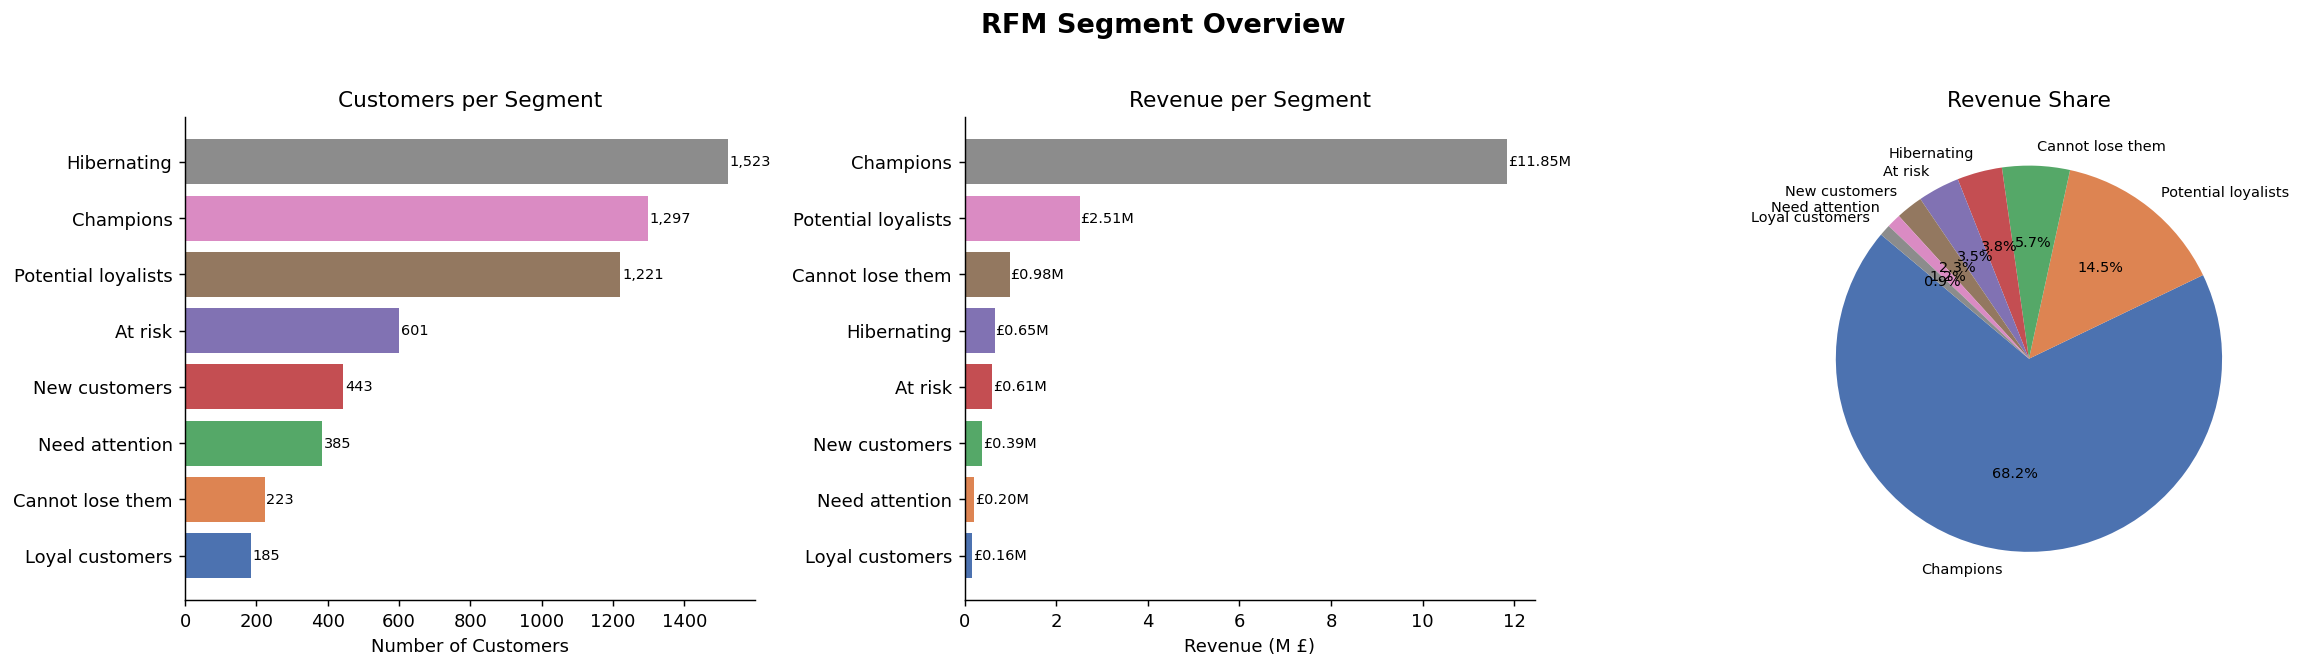

In [14]:
plot_segment_overview(segment_summary, palette=PALETTE)


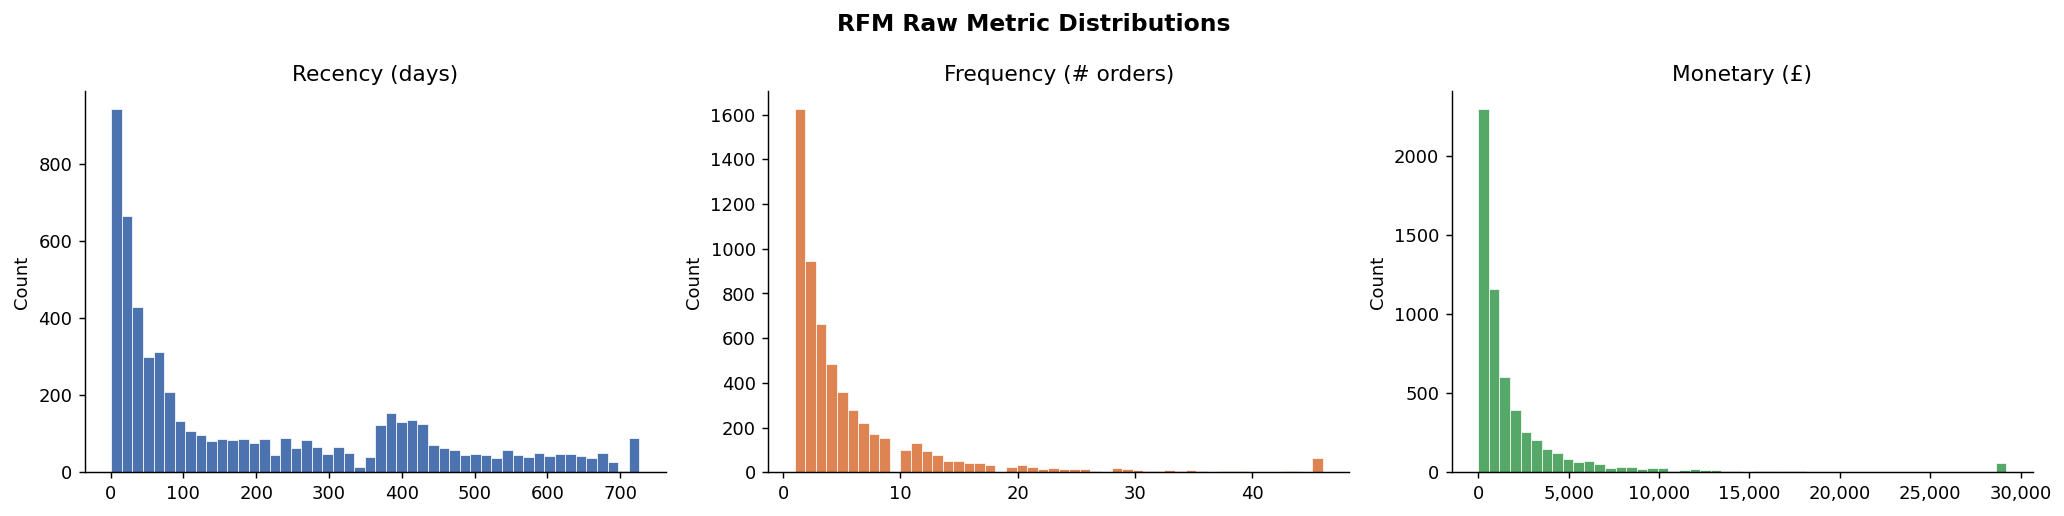

In [15]:
plot_rfm_distributions(rfm)


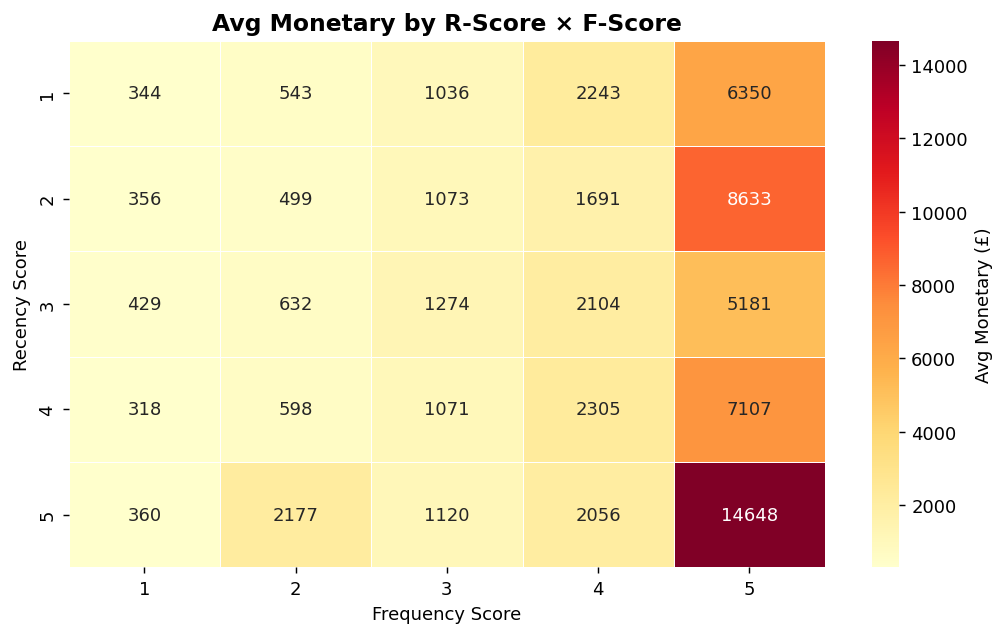

In [16]:
plot_rfm_heatmap(rfm)


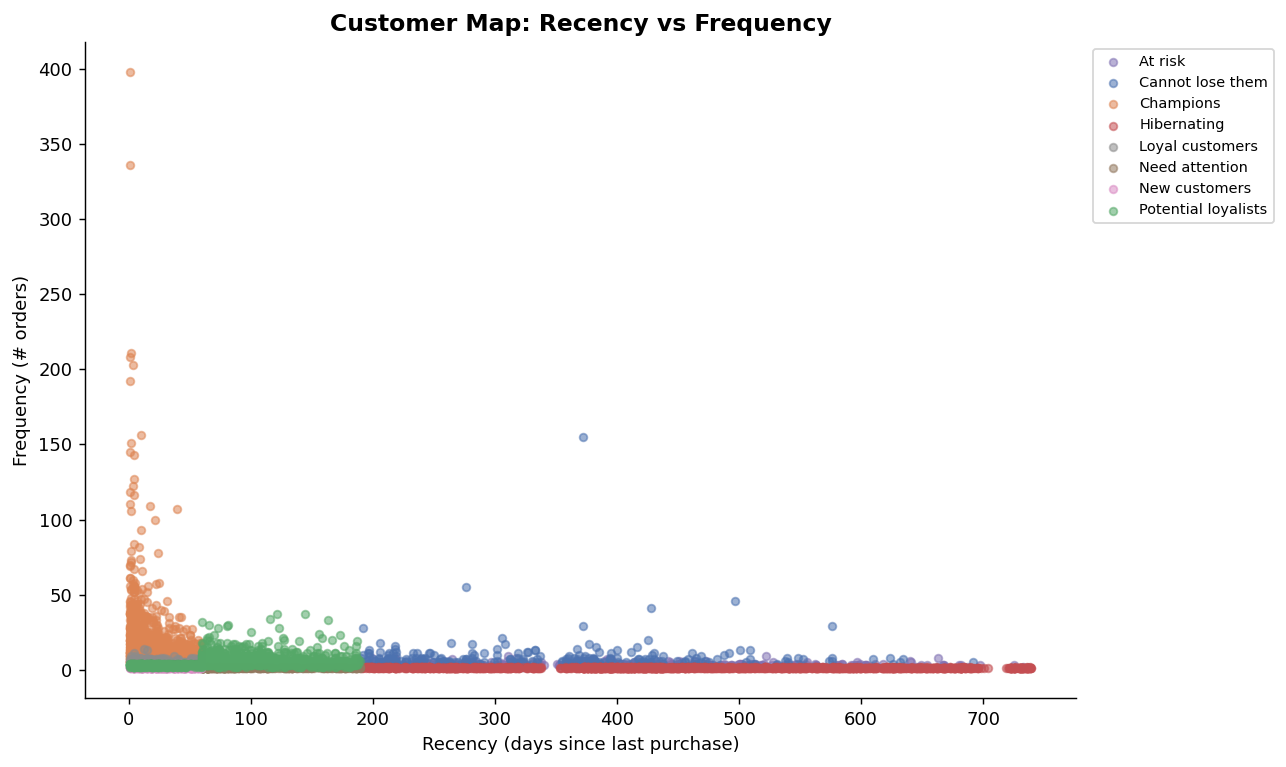

In [17]:
plot_scatter_rf(rfm, palette=PALETTE)


## 5 · Customer Lifetime Value (CLV) Estimation

In [18]:
# --- Tenure / observation-window based CLV (modular) ---
rfm = add_clv_tenure(rfm, df, horizon_months=12, min_obs_days=30)

clv_by_segment = (
    rfm.groupby("Segment")["CLV_12M"]
       .agg(["mean", "median", "sum"])
       .rename(columns={"mean": "Avg CLV", "median": "Median CLV", "sum": "Total CLV"})
       .sort_values("Total CLV", ascending=False)
       .style.format("£{:,.0f}")
)
clv_by_segment


,Avg CLV,Median CLV,Total CLV
Segment,,,
Champions,"£5,800","£2,699","£7,522,292"
Potential loyalists,"£2,151","£1,108","£2,626,298"
New customers,"£3,843","£2,019","£1,702,631"
Need attention,"£1,427",£900,"£549,536"
Hibernating,£345,£206,"£524,867"
Cannot lose them,"£2,337","£1,287","£521,212"
At risk,£668,£488,"£401,549"
Loyal customers,"£1,109",£646,"£205,173"


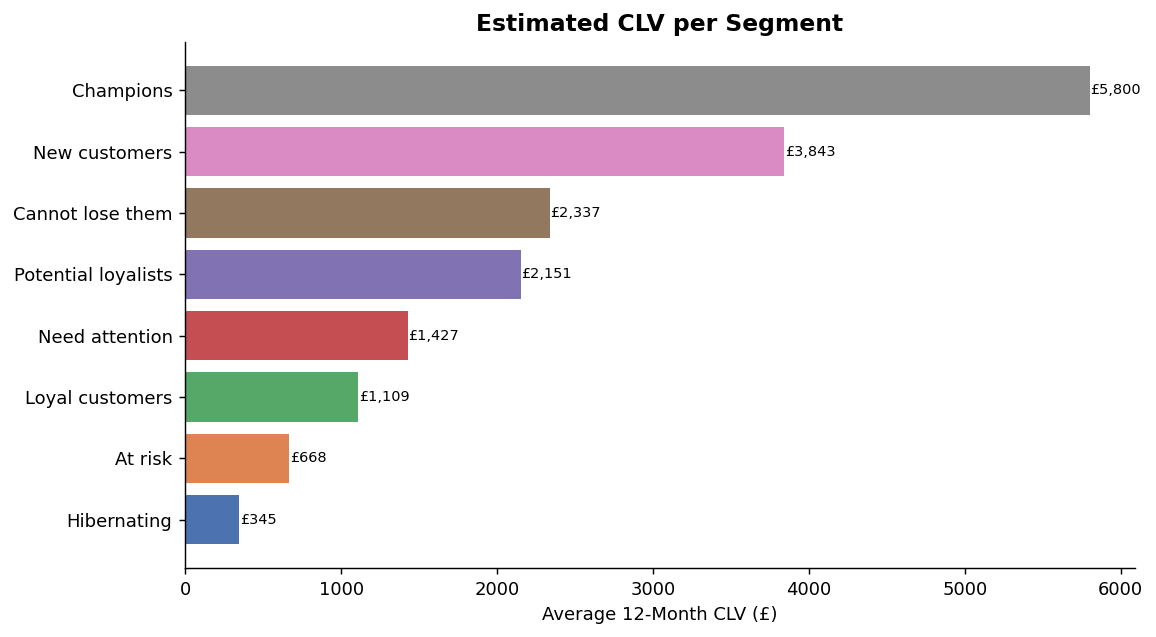

In [19]:
# CLV bar chart
clv_df = (
    rfm.groupby("Segment")["CLV_12M"]
       .mean()
       .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(clv_df.index, clv_df.values, color=PALETTE[:len(clv_df)])
ax.set_xlabel("Average 12-Month CLV (£)")
ax.set_title("Estimated CLV per Segment", fontsize=13, fontweight="bold")
for bar, val in zip(bars, clv_df.values):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"£{val:,.0f}", va="center", fontsize=8)
plt.tight_layout()
plt.savefig("clv_by_segment.png", bbox_inches="tight")
plt.show()


## 6 · K-Means Clustering

In [20]:
X_scaled = prepare_rfm_for_clustering(rfm)
print(f"Feature matrix shape: {X_scaled.shape}")


Feature matrix shape: (5878, 3)


In [21]:
k_range = range(2, 11)
results = find_optimal_k(X_scaled, k_range)

# Print curves for quick inspection
for k, inertia, sil in zip(results["k_values"], results["inertias"], results["silhouettes"]):
    print(f"  k={k}  inertia={inertia:,.0f}  silhouette={sil:.4f}")


  k=2  inertia=8,590  silhouette=0.4390
  k=3  inertia=6,355  silhouette=0.3494
  k=4  inertia=4,923  silhouette=0.3667
  k=5  inertia=4,099  silhouette=0.3422
  k=6  inertia=3,555  silhouette=0.3334
  k=7  inertia=3,209  silhouette=0.3227
  k=8  inertia=2,902  silhouette=0.2975
  k=9  inertia=2,696  silhouette=0.2771
  k=10  inertia=2,476  silhouette=0.2818


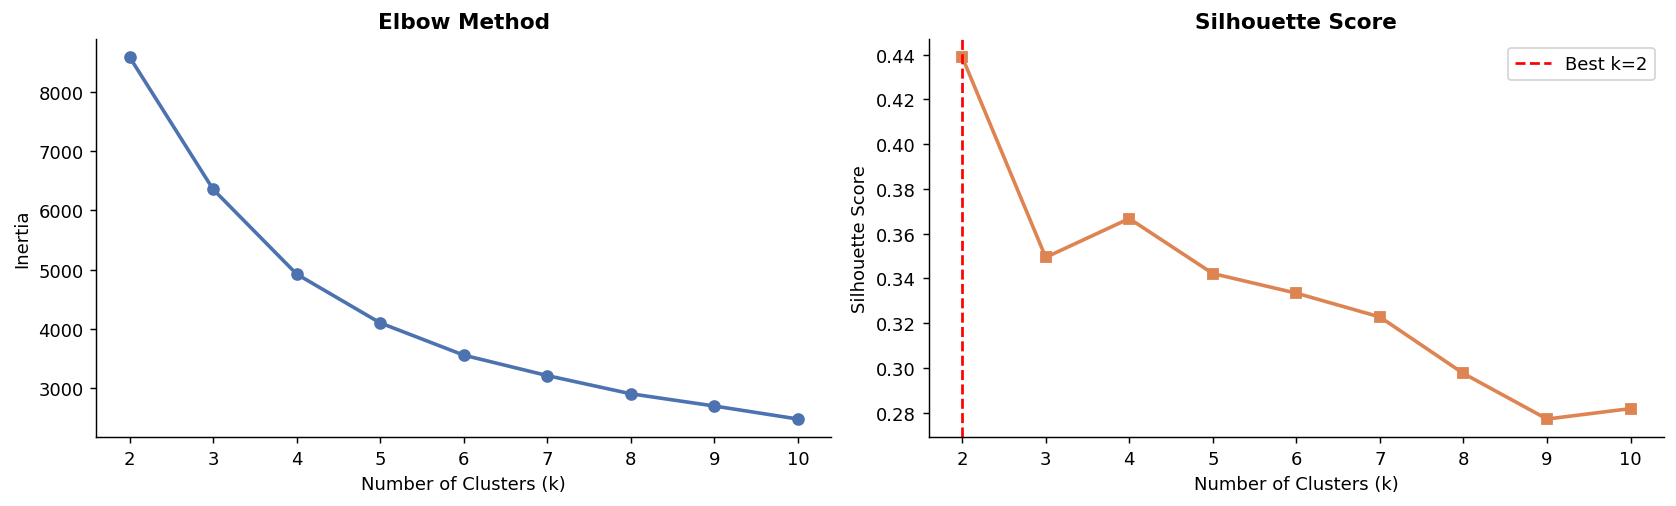

Recommended k = 2  (highest silhouette)


2

In [22]:
plot_elbow_silhouette(results)


In [23]:
# ── Fit final model with best k ─────────────────────────────────────────────
BEST_K = results["k_values"][np.argmax(results["silhouettes"])]

km_final = KMeans(n_clusters=BEST_K, random_state=42, n_init="auto")
rfm["KMeans_Cluster"] = km_final.fit_predict(X_scaled)

# reset_index: add_clv_tenure sets CustomerID as index; restore it as a column for groupby
rfm = rfm.reset_index()

# ── Cluster profiles ─────────────────────────────────────────────────────────
cluster_profile = (
    rfm.groupby("KMeans_Cluster")
       .agg(
           n_customers  =("CustomerID",  "count"),
           avg_recency  =("recency",     "mean"),
           avg_frequency=("frequency",   "mean"),
           avg_monetary =("monetary",    "mean"),
           avg_clv      =("CLV_12M",     "mean"),
       )
       .round(1)
       .sort_values("avg_monetary", ascending=False)
)
print(cluster_profile.to_string())


                n_customers  avg_recency  avg_frequency  avg_monetary  avg_clv
KMeans_Cluster                                                                
1                      2299         49.9           12.8        6586.9   4761.9
0                      3579        298.6            2.1         621.1    867.8


In [24]:
cluster_labels = label_kmeans_clusters(cluster_profile)
rfm["KMeans_Label"] = rfm["KMeans_Cluster"].map(cluster_labels)

print(rfm["KMeans_Label"].value_counts())


KMeans_Label
Mid-Value Regulars    3579
High-Value Active     2299
Name: count, dtype: int64


## 7 · Final Summary

In [26]:
total_customers = len(rfm)
total_revenue   = rfm["monetary"].sum()
top_segment     = segment_summary.iloc[0]

print("=" * 55)
print("  RFM Analysis — Executive Summary")
print("=" * 55)
print(f"  Total customers analysed : {total_customers:,}")
print(f"  Total revenue (dataset)  : £{total_revenue:,.0f}")
print(f"  Top segment by revenue   : {top_segment['Segment']}")
print(f"    └─ customers  : {top_segment['customers']:,}")
print(f"    └─ revenue    : £{top_segment['revenue']:,.0f}")
print(f"  K-Means clusters         : {BEST_K}")
print("=" * 55)


  RFM Analysis — Executive Summary
  Total customers analysed : 5,878
  Total revenue (dataset)  : £17,366,041
  Top segment by revenue   : Champions
    └─ customers  : 1,297
    └─ revenue    : £11,851,124
  K-Means clusters         : 2
